# Can the Arterial Line Predict Kidney Injury?

## Intraoperative Blood Pressure Dynamics and Acute Kidney Injury

During surgery, one of the most important monitors we have is the **arterial line** — a thin catheter placed directly into an artery (usually the radial artery at the wrist). Unlike a standard blood pressure cuff that checks every few minutes, the arterial line gives us a continuous, beat-by-beat picture of a patient's blood pressure. Every heartbeat produces a new reading — systolic (the peak), diastolic (the trough), and mean arterial pressure (MAP, the average perfusion pressure).

Why does this matter for the kidneys? The kidneys are remarkably sensitive to blood pressure. They receive about 20–25% of the entire cardiac output, and they depend on a minimum perfusion pressure to filter waste products from the blood. When blood pressure drops during surgery — a common event during anaesthesia — the kidneys may not receive enough blood flow. If this happens for long enough or drops low enough, the result can be **acute kidney injury (AKI)**: a sudden decline in kidney function that increases the length of hospital stay, the risk of chronic kidney disease, and even mortality.

### What is AKI and how do we detect it?

AKI is defined by the **KDIGO criteria** (Kidney Disease: Improving Global Outcomes). In simple terms, we compare a patient's kidney function *before* surgery to *after* surgery by measuring **creatinine** — a waste product in the blood that healthy kidneys normally clear. If post-operative creatinine rises to 1.5 times the baseline value, or jumps by 0.3 mg/dL or more within 7 days, the patient has AKI.

### What will you learn in this notebook?

In this notebook, we take 100 surgical cases from the VitalDB dataset — 50 who developed AKI and 50 who did not — and ask a series of practical questions:

1. **Can we see the difference?** Do the raw arterial traces *look* different between patients who develop AKI and those who do not?
2. **Which numbers matter?** We extract features like mean MAP, time spent below critical thresholds, and blood pressure variability, then compare the two groups.
3. **Is there a "safe" MAP threshold?** We scan multiple MAP cutoffs (55, 60, 65, 70, 75 mmHg) to find which one best distinguishes AKI from non-AKI patients.
4. **Is there a dose–response relationship?** In pharmacology, "the dose makes the poison." Does the same apply here — does *more* hypotension mean *more* kidney damage?
5. **Can we build a predictive model?** Using logistic regression on arterial line features alone, how well can we predict which patients will develop AKI?

> **Cohort:** 100 cases with invasive arterial lines (50 AKI, 50 No AKI), stratified from 2,443 labelled cases in the VitalDB database (Seoul National University Hospital).
>
> **Signals:** Beat-to-beat SBP, DBP, and MBP from the Solar8000 monitor, cached locally from the VitalDB API.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

CACHE = Path('/Volumes/iDrisAI/VitalDBGit/art_cache')
DATA_DIR = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')

## 1. What does our dataset look like?

Before we do any analysis, let's load our data and get a feel for it. We have arterial line recordings from 100 surgical cases — half developed AKI, half did not. The arterial line readings have been cached as Parquet files (a fast data format) from the VitalDB API.

We also apply a **plausibility filter**: any blood pressure reading that falls outside physiologically reasonable bounds (for example, a MAP below 20 or above 180 mmHg) is removed. These extreme values are almost always artefacts — caused by the line being flushed, kinked, or momentarily disconnected — rather than true patient physiology.

In [2]:
labels = pd.read_csv(CACHE / 'labels.csv')
print(f'Labelled cases   : {len(labels)}')
print(f'AKI              : {labels["aki_any"].sum()} ({labels["aki_any"].mean()*100:.0f}%)')
print(f'No AKI           : {(labels["aki_any"]==0).sum()}')
print(f'Baseline Cr mean : {labels["cr_base"].mean():.2f} ± {labels["cr_base"].std():.2f} mg/dL')
print(f'Peak Cr mean     : {labels["cr_peak"].mean():.2f} ± {labels["cr_peak"].std():.2f} mg/dL')

# Load all parquet files into one DataFrame
parquets = sorted(CACHE.glob('*.parquet'))
art_raw = pd.concat([pd.read_parquet(p) for p in parquets], ignore_index=True)
art_raw = art_raw.merge(labels[['caseid','aki_any','cr_base','cr_peak','cr_ratio','cr_delta']], on='caseid')

# Plausibility filter per signal
limits = {'ART_MBP': (20, 180), 'ART_SBP': (40, 260), 'ART_DBP': (10, 150)}
mask = art_raw.apply(lambda r: limits[r['signal']][0] <= r['value'] <= limits[r['signal']][1], axis=1)
art = art_raw[mask].copy()

print(f'\nTotal data points : {len(art_raw):,}')
print(f'After filter      : {len(art):,} ({len(art)/len(art_raw)*100:.1f}% retained)')
print(f'Cases loaded      : {art["caseid"].nunique()}')

Labelled cases   : 100
AKI              : 50 (50%)
No AKI           : 50
Baseline Cr mean : 1.85 ± 2.99 mg/dL
Peak Cr mean     : 2.49 ± 3.94 mg/dL



Total data points : 2,200,560
After filter      : 2,078,081 (94.4% retained)
Cases loaded      : 98


## 2. Can we see the difference with our own eyes?

Before running any statistics, let's simply *look* at the arterial traces. Below, we plot the full intraoperative blood pressure recording for four AKI cases (left column) and four non-AKI cases (right column). Each panel shows three traces: systolic (blue), mean (orange), and diastolic (teal) arterial pressure over time.

The red dashed line marks MAP 65 mmHg — a commonly cited threshold below which organ perfusion may become compromised. The darker dotted line marks MAP 55 mmHg — a level associated with more severe hypoperfusion.

**What to look for:** Do the AKI traces spend more time below the red dashed line? Are there prolonged dips? Is the blood pressure more "jagged" or unstable?

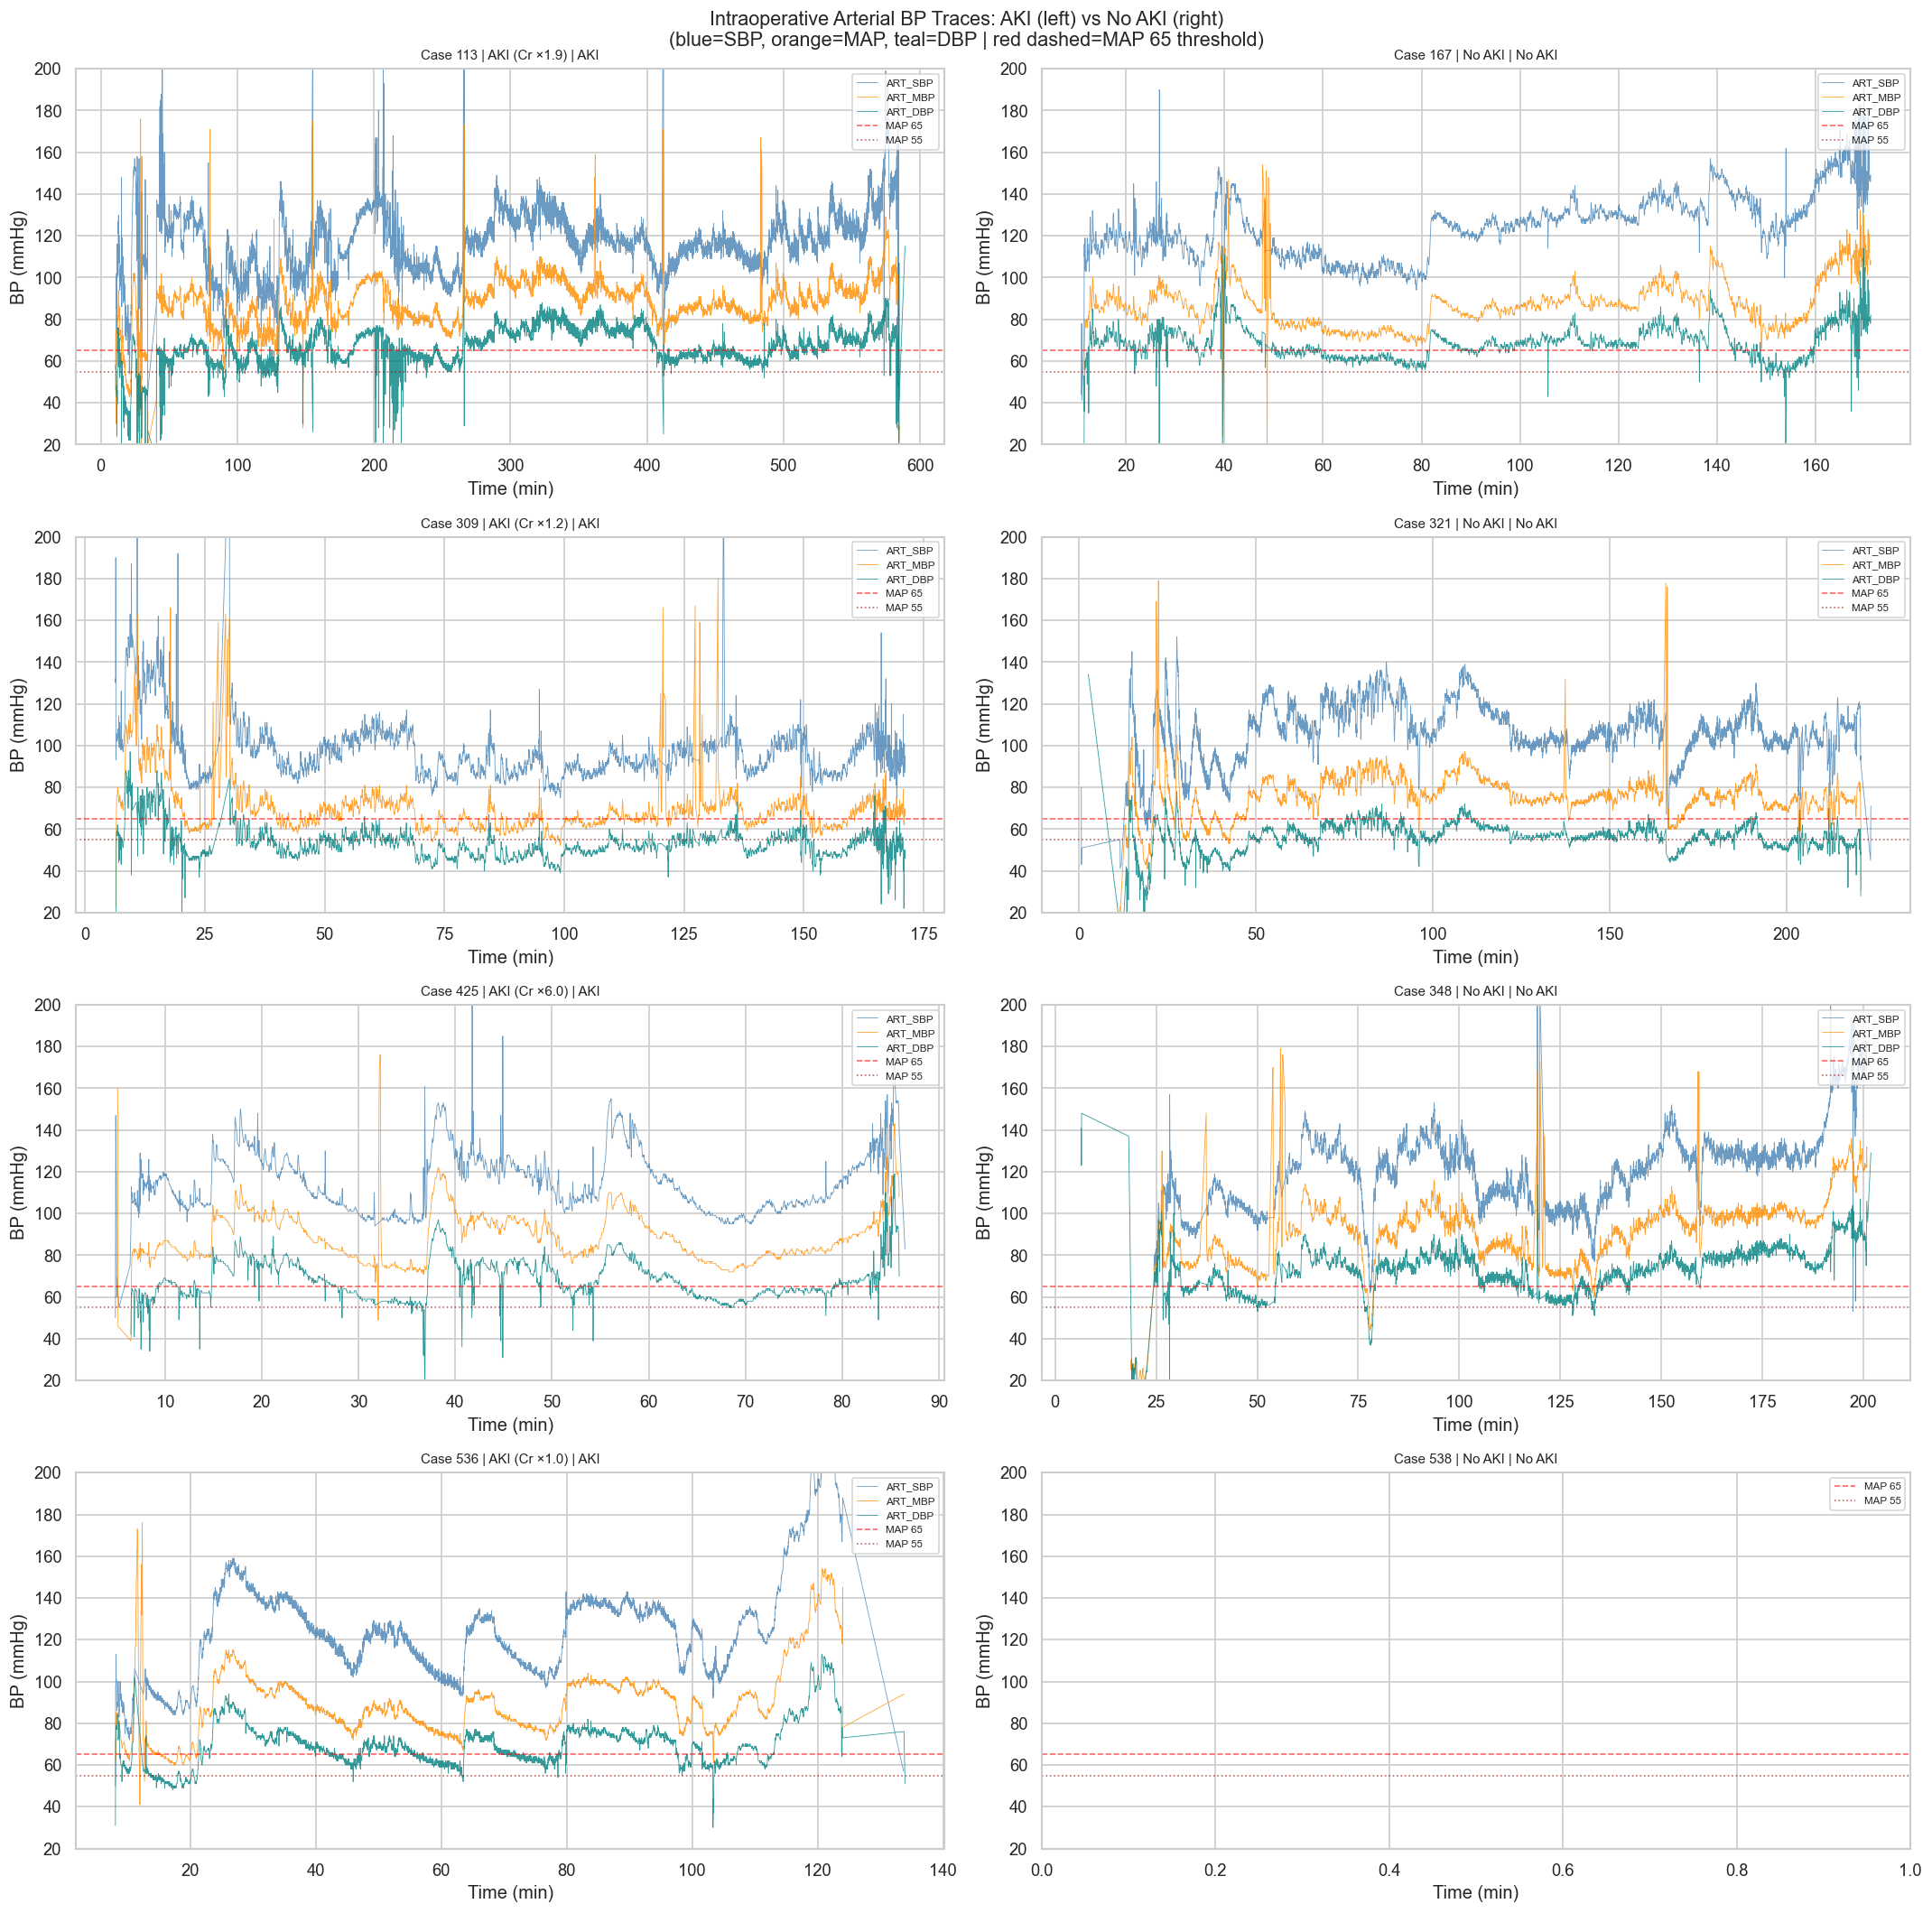

In [3]:
def plot_case(caseid, ax, title_suffix=''):
    """Plot SBP/MAP/DBP traces for one case on a given axis."""
    sub = art[art['caseid'] == caseid].copy()
    sub['time_min'] = sub['time_s'] / 60
    colors = {'ART_SBP': 'steelblue', 'ART_MBP': 'darkorange', 'ART_DBP': 'teal'}
    for sig, color in colors.items():
        s = sub[sub['signal'] == sig]
        if len(s) == 0: continue
        ax.plot(s['time_min'], s['value'], color=color, linewidth=0.5, alpha=0.8, label=sig)
    ax.axhline(65, color='red', linestyle='--', linewidth=1, alpha=0.6, label='MAP 65')
    ax.axhline(55, color='darkred', linestyle=':', linewidth=1, alpha=0.6, label='MAP 55')
    ax.set_ylim(20, 200)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('BP (mmHg)')
    row = labels[labels['caseid'] == caseid].iloc[0]
    aki_str = f'AKI (Cr ×{row.cr_ratio:.1f})' if row.aki_any == 1 else 'No AKI'
    ax.set_title(f'Case {caseid} | {aki_str} | {title_suffix}', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

aki_ids   = labels[labels['aki_any']==1]['caseid'].tolist()[:4]
noaki_ids = labels[labels['aki_any']==0]['caseid'].tolist()[:4]

fig, axes = plt.subplots(4, 2, figsize=(18, 18))
for i, (cid_aki, cid_noaki) in enumerate(zip(aki_ids, noaki_ids)):
    plot_case(cid_aki,   axes[i][0], 'AKI')
    plot_case(cid_noaki, axes[i][1], 'No AKI')

plt.suptitle('Intraoperative Arterial BP Traces: AKI (left) vs No AKI (right)\n'
             '(blue=SBP, orange=MAP, teal=DBP | red dashed=MAP 65 threshold)',
             fontsize=13)
plt.tight_layout()
plt.show()

### What do we see?

Even at a glance, several patterns often emerge:

- **AKI cases tend to have more frequent and deeper dips below the MAP 65 line.** You may notice the orange (MAP) trace spending extended periods in the "danger zone" below the dashed red line.
- **Non-AKI cases tend to have more stable traces** that hover well above the thresholds for most of the operation.
- **Some AKI patients show dramatic swings** — the blood pressure oscillates widely, suggesting haemodynamic instability rather than a single sustained drop.

Of course, individual cases vary enormously. Some AKI patients may have relatively normal-looking traces (suggesting their kidney injury had other causes — pre-existing renal disease, nephrotoxic drugs, or embolic events). And some non-AKI patients may have dipped below MAP 65 briefly without lasting harm. This is why we need to move beyond individual cases and quantify these patterns across the whole cohort.

## 3. How do we turn a blood pressure trace into numbers?

A raw arterial line trace can contain tens of thousands of data points per patient. To compare patients, we need to distil each trace into a handful of meaningful summary numbers — what data scientists call **features**. Here is what we extract for each case:

| Feature | What it captures | Why it matters clinically |
|---------|-----------------|-------------------------|
| **Mean MAP** | The average perfusion pressure across the whole case | A lower average suggests the kidneys spent more time under-perfused |
| **% Time MAP < 65** | The fraction of the operation spent below the 65 mmHg threshold | Captures the *duration* of hypotension — even brief dips add up |
| **MAP deficit-minutes (AUC < 65)** | The cumulative "depth x duration" of hypotension below 65 | Captures both how *far* and how *long* MAP dropped — a more sensitive measure than percentage alone |
| **Longest hypotension run** | The longest unbroken stretch of readings below MAP 65 | Sustained hypotension is more damaging than the same total time in short bursts |
| **SBP variability (successive squared differences)** | How much systolic pressure changes from one beat to the next | High beat-to-beat lability may reflect poor cardiovascular reserve or light anaesthesia |
| **Pulse pressure** | The gap between systolic and diastolic pressure | Very narrow pulse pressure can signal low cardiac output; very wide pulse pressure can signal stiff, non-compliant vessels |

In [4]:
def extract_features(caseid, df):
    """Extract rich hemodynamic features from one case's ART traces."""
    feat = {'caseid': caseid}
    mbp = df[df['signal'] == 'ART_MBP']['value'].values
    sbp = df[df['signal'] == 'ART_SBP']['value'].values
    dbp = df[df['signal'] == 'ART_DBP']['value'].values
    t   = df[df['signal'] == 'ART_MBP']['time_s'].values

    if len(mbp) < 20 or len(t) < 20:
        return None

    # --- MAP statistics ---
    feat['map_mean']   = mbp.mean()
    feat['map_median'] = np.median(mbp)
    feat['map_min']    = mbp.min()
    feat['map_sd']     = mbp.std()
    feat['map_cv']     = mbp.std() / mbp.mean() * 100

    # --- Hypotension thresholds ---
    for thr in [55, 60, 65, 70, 75]:
        feat[f'pct_map_lt{thr}'] = (mbp < thr).mean() * 100

    # --- Hypertension ---
    feat['pct_map_gt100'] = (mbp > 100).mean() * 100
    feat['pct_map_gt110'] = (mbp > 110).mean() * 100

    # --- Time-weighted MAP deficit (area under threshold) ---
    if len(t) > 1:
        dt = np.diff(t) / 60  # seconds → minutes
        for thr in [65, 75]:
            deficit = np.maximum(0, thr - mbp[:-1])
            feat[f'auc_lt{thr}'] = float((deficit * dt).sum())

    # --- Longest continuous hypotension episode (MAP < 65) ---
    hypo = (mbp < 65).astype(int)
    if hypo.any():
        # count consecutive runs
        runs = np.diff(np.concatenate([[0], hypo, [0]]))
        starts = np.where(runs == 1)[0]
        ends   = np.where(runs == -1)[0]
        lengths = ends - starts
        feat['max_hypo_run'] = int(lengths.max()) if len(lengths) else 0
        feat['n_hypo_episodes'] = len(lengths)
    else:
        feat['max_hypo_run'] = 0
        feat['n_hypo_episodes'] = 0

    # --- SBP statistics ---
    if len(sbp) > 10:
        feat['sbp_mean'] = sbp.mean()
        feat['sbp_sd']   = sbp.std()
        feat['sbp_min']  = sbp.min()
        feat['sbp_max']  = sbp.max()
        # SBP variability by successive differences (beat-to-beat lability)
        feat['sbp_ssd']  = np.sqrt(np.mean(np.diff(sbp)**2))  # successive squared differences

    # --- Pulse pressure ---
    if len(sbp) > 10 and len(dbp) > 10:
        n = min(len(sbp), len(dbp))
        pp = sbp[:n] - dbp[:n]
        feat['pp_mean'] = pp.mean()
        feat['pp_sd']   = pp.std()
        feat['pct_pp_narrow'] = (pp < 20).mean() * 100  # narrow PP → low CO
        feat['pct_pp_wide']   = (pp > 60).mean() * 100  # wide PP → high afterload

    # --- Case duration ---
    feat['duration_min'] = (t.max() - t.min()) / 60

    return feat

records = []
for cid, grp in art.groupby('caseid'):
    f = extract_features(cid, grp)
    if f: records.append(f)

hemo = pd.DataFrame(records)
hemo = hemo.merge(labels[['caseid','aki_any','cr_base','cr_peak','cr_ratio','cr_delta',
                            'age','sex','asa','death_inhosp','icu_days']], on='caseid')
print(f'Cases with full features: {len(hemo)}')
print(f'AKI: {hemo["aki_any"].sum()}  |  No AKI: {(hemo["aki_any"]==0).sum()}')
hemo[['map_mean','map_min','map_sd','pct_map_lt65','auc_lt65','sbp_ssd','pp_mean']].describe().round(1)

Cases with full features: 97
AKI: 49  |  No AKI: 48


,map_mean,map_min,map_sd,pct_map_lt65,auc_lt65,sbp_ssd,pp_mean
count,97.0,97.0,97.0,97.0,97.0,97.0,97.0
mean,81.4,27.1,13.2,12.7,395.2,4.6,53.5
std,9.4,10.7,2.7,18.6,913.0,1.3,10.7
min,51.8,20.0,6.8,0.0,0.0,2.2,30.5
25%,76.0,20.0,11.1,1.7,32.6,3.7,47.5
50%,81.9,22.0,13.0,5.9,103.1,4.3,53.7
75%,87.7,28.0,14.9,14.5,347.0,5.2,59.7
max,103.5,65.0,20.2,93.9,5433.8,9.2,104.0


### Reading the summary table

The table above shows the distribution of our extracted features across all 97 cases. A few things to note:

- **Mean MAP** averages about 81 mmHg with a range from about 52 to 104. This tells us most patients had "acceptable" average pressures, but the extremes are striking — one patient averaged a MAP of only 52, which is dangerously low.
- **% Time MAP < 65** has a median of about 6%, but ranges all the way up to 94%. That top-end patient spent nearly the entire operation hypotensive.
- **MAP deficit-minutes** (AUC < 65) has enormous spread — from 0 (never hypotensive) to over 5,400. This metric is the most sensitive because it accounts for both depth and duration.

Now let's see whether these features actually differ between patients who developed AKI and those who did not.

## 4. Do the numbers differ between AKI and non-AKI patients?

Now we put each feature to the test. The box plots below compare AKI patients (red) to non-AKI patients (blue) for eight haemodynamic features. Each panel also shows the result of a **Mann–Whitney U test** — a statistical test that asks: "Are these two groups drawn from the same distribution, or is one systematically higher/lower than the other?"

**A quick primer on the p-value:** The p-value tells you how likely it is that you would see a difference this large (or larger) purely by chance, *if there were truly no difference between the groups*. By convention:
- **p < 0.05** means the difference is "statistically significant" — unlikely to be due to chance alone.
- **p < 0.01** is stronger evidence, and **p < 0.001** is very strong.
- A large p-value (say, p = 0.65) means we cannot distinguish the groups — the difference could easily be random noise.

**Why Mann–Whitney rather than a t-test?** The t-test assumes data follow a bell-shaped (normal) distribution. Blood pressure metrics are often skewed — think of hypotension duration, which has many zeros and a long right tail. The Mann–Whitney test makes no assumption about the shape of the data; it simply asks whether values in one group tend to be higher than in the other.

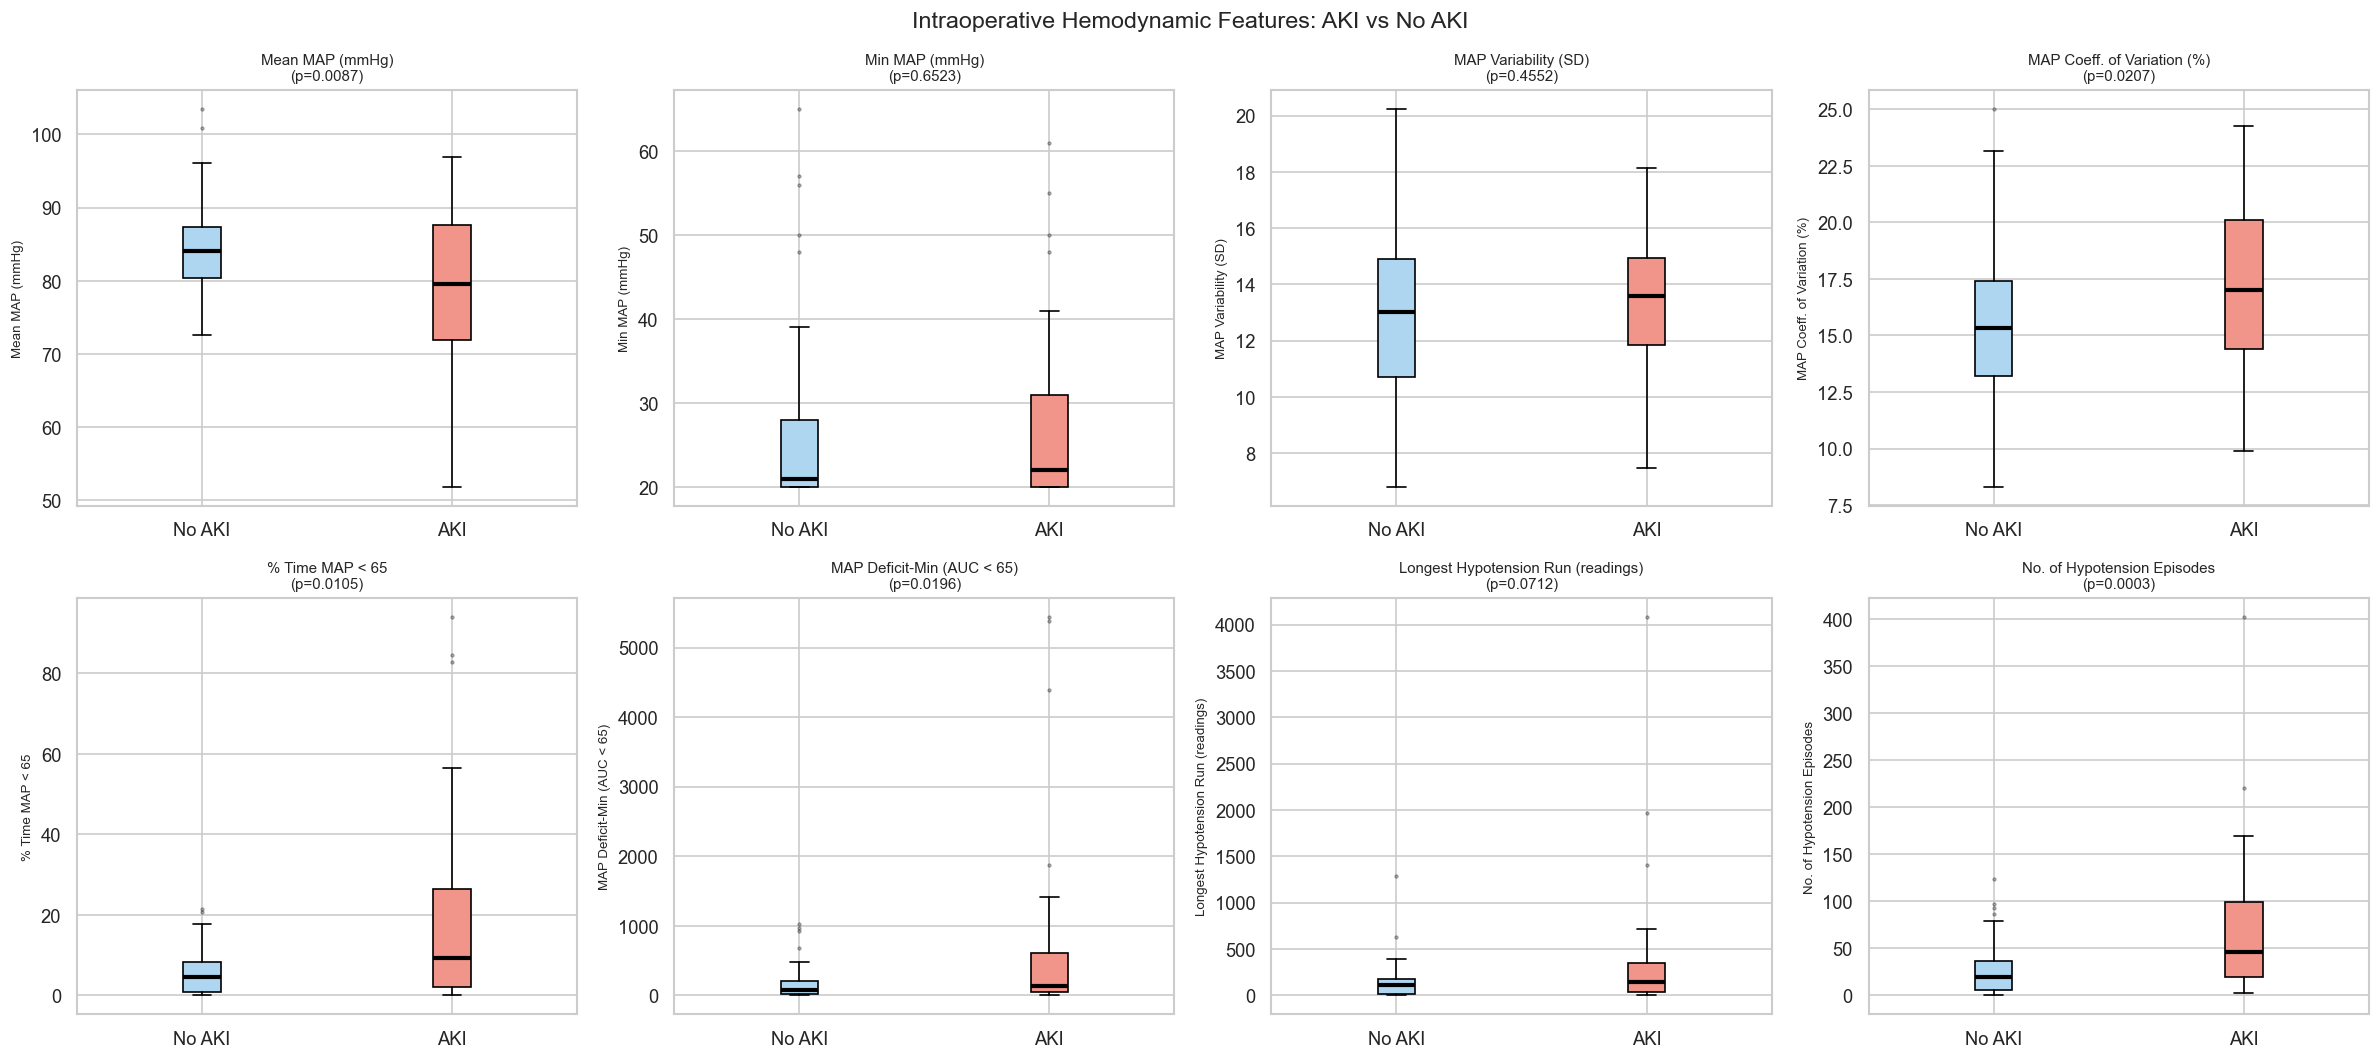

In [5]:
aki_df   = hemo[hemo['aki_any'] == 1]
noaki_df = hemo[hemo['aki_any'] == 0]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
pairs = [
    ('map_mean',       'Mean MAP (mmHg)'),
    ('map_min',        'Min MAP (mmHg)'),
    ('map_sd',         'MAP Variability (SD)'),
    ('map_cv',         'MAP Coeff. of Variation (%)'),
    ('pct_map_lt65',   '% Time MAP < 65'),
    ('auc_lt65',       'MAP Deficit-Min (AUC < 65)'),
    ('max_hypo_run',   'Longest Hypotension Run (readings)'),
    ('n_hypo_episodes','No. of Hypotension Episodes'),
]

for ax, (col, title) in zip(axes.flatten(), pairs):
    g0 = noaki_df[col].dropna()
    g1 = aki_df[col].dropna()
    _, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    pstr = f'p={p:.4f}' if p >= 0.0001 else 'p<0.0001'

    bp = ax.boxplot([g0, g1], labels=['No AKI', 'AKI'],
                    patch_artist=True, showfliers=True,
                    flierprops=dict(marker='.', markersize=3, alpha=0.4),
                    medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#F1948A')

    ax.set_title(f'{title}\n({pstr})', fontsize=9)
    ax.set_ylabel(title, fontsize=8)

plt.suptitle('Intraoperative Hemodynamic Features: AKI vs No AKI', fontsize=14)
plt.tight_layout()
plt.show()

### What do these box plots tell us?

The key findings from this comparison:

- **Mean MAP is significantly lower in AKI patients** (p ~ 0.009). AKI patients ran at a lower average perfusion pressure throughout their operations — about 80 mmHg versus 84 mmHg in the non-AKI group. That 4-point difference may seem small, but at the population level it reflects a meaningful shift.
- **% Time MAP < 65** and **MAP deficit-minutes** are both significantly higher in the AKI group (p ~ 0.01–0.02). AKI patients spent roughly twice as much time below the critical threshold and accumulated more cumulative hypotensive burden.
- **Minimum MAP** does *not* significantly differ between groups (p ~ 0.65). This is an important negative finding: a single brief nadir may not matter as much as the overall burden. Almost everyone has a brief dip at induction; what matters is how quickly you recover.
- **MAP variability** (SD and CV) shows modest differences. Some variability may reflect normal responses to surgical stimulation, while excessive swings may indicate cardiovascular fragility.

**The clinical take-away:** It is not just *how low* the blood pressure drops that matters — it is *how long* it stays low. Duration and cumulative burden appear to be stronger predictors of kidney injury than a single minimum value.

## 5. What does the "average" operation look like for each group?

Individual cases are noisy. To see the forest for the trees, we can create a **population-averaged MAP profile**: we normalise each case's time axis from 0% (start of surgery) to 100% (end of surgery), then stack all the traces and plot the median and interquartile range (IQR — the middle 50% of values) for each group.

This gives us a bird's-eye view: at any point during the operation, what is the *typical* MAP for an AKI patient versus a non-AKI patient?

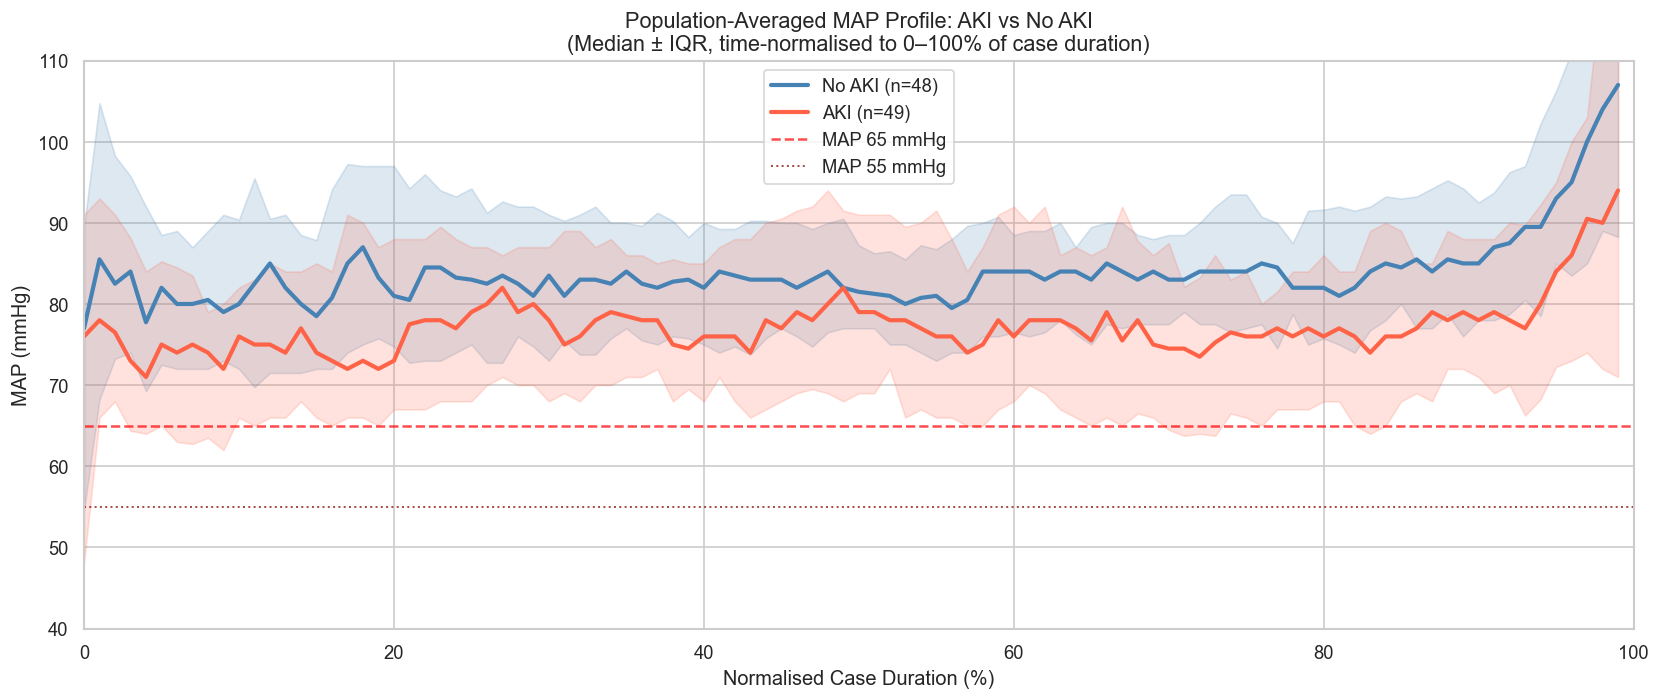

In [6]:
N_BINS = 100
traces = {0: [], 1: []}

for cid, grp in art[art['signal']=='ART_MBP'].groupby('caseid'):
    vals = grp.sort_values('time_s')
    t = vals['time_s'].values
    v = vals['value'].values
    if len(v) < 30: continue
    t_norm = (t - t.min()) / (t.max() - t.min()) * 100
    bins = np.floor(t_norm / (100/N_BINS)).astype(int).clip(0, N_BINS-1)
    trace = pd.Series(v).groupby(bins).median()
    trace.index = trace.index.astype(int)
    full = pd.Series(index=np.arange(N_BINS), dtype=float)
    full.update(trace)
    aki_val = grp['aki_any'].iloc[0]
    traces[aki_val].append(full.values)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(N_BINS)
colors_map = {0: ('steelblue', 'No AKI'), 1: ('tomato', 'AKI')}

for aki_val, (color, label) in colors_map.items():
    mat = np.array(traces[aki_val])
    med = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    ax.plot(x, med, color=color, linewidth=2.5, label=f'{label} (n={len(traces[aki_val])})')
    ax.fill_between(x, q25, q75, color=color, alpha=0.18)

ax.axhline(65, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='MAP 65 mmHg')
ax.axhline(55, color='darkred', linestyle=':', linewidth=1.2, alpha=0.7, label='MAP 55 mmHg')
ax.set_xlim(0, N_BINS)
ax.set_ylim(40, 110)
ax.set_xlabel('Normalised Case Duration (%)', fontsize=12)
ax.set_ylabel('MAP (mmHg)', fontsize=12)
ax.set_title('Population-Averaged MAP Profile: AKI vs No AKI\n'
             '(Median ± IQR, time-normalised to 0–100% of case duration)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Reading the population MAP profile

Several important patterns emerge:

- **The AKI group runs consistently lower** throughout the operation — not just at one moment, but across the entire normalised timeline. The gap between the two median lines is relatively constant, suggesting a persistent perfusion deficit rather than a single catastrophic event.
- **The shaded bands (IQR) overlap substantially.** This means there is a great deal of individual variation within each group. Some AKI patients had higher MAPs than some non-AKI patients, and vice versa. Hypotension is a *risk factor*, not a deterministic cause.
- **Both groups show a characteristic dip early in the case** (around 5–15% of case duration) — this corresponds to the haemodynamic effects of anaesthetic induction, when blood pressure often falls as anaesthetic agents cause vasodilation and myocardial depression. The subsequent recovery reflects the anaesthetist's interventions (fluids, vasopressors, lightening of anaesthesia).
- **The AKI group's IQR extends closer to the MAP 65 threshold**, meaning that a larger proportion of AKI patients hover near or below the "danger zone" at any given point during surgery.

**Clinical implication:** This profile supports the idea that AKI risk is driven by *cumulative* haemodynamic insult over the course of the operation, not by isolated hypotensive events.

## 6. Is MAP 65 really the "magic number"? A threshold scan

In clinical practice, MAP 65 mmHg is widely cited as the minimum acceptable blood pressure during anaesthesia. But where does this number come from? Is it truly the best threshold for predicting kidney injury, or is it just a convenient round number that has become dogma?

To answer this, we perform a **threshold scan**: for each MAP cutoff from 55 to 75 mmHg, we calculate the percentage of time each patient spent below that threshold, then test whether this percentage differs between AKI and non-AKI groups.

We use two metrics:
- **The p-value** (plotted as -log10 for easier reading — taller bars = more significant). This tells us how confidently we can say the two groups differ at that threshold.
- **The point-biserial correlation (r)**: a measure of the *strength* of the association between the continuous variable (% time below threshold) and the binary outcome (AKI yes/no). Values range from -1 to +1; values near 0 mean no relationship, while values further from 0 mean a stronger association.

**What to expect:** If MAP 65 is truly the critical threshold, we would expect it to show the strongest signal. But the kidney's autoregulatory range varies between patients — older patients, those with chronic hypertension, or those with pre-existing renal disease may lose autoregulation at higher MAPs. So a threshold of 70 or 75 might actually be more predictive.

 threshold_mmHg  p_value     r_pb  mean_noaki  mean_aki
             55 0.105241 0.250329    0.982817  6.218519
             60 0.054947 0.290561    2.219267 10.865054
             65 0.010532 0.363888    5.905950 19.359818
             70 0.002592 0.394203   12.374262 30.643825
             75 0.002038 0.380596   23.714785 43.428418


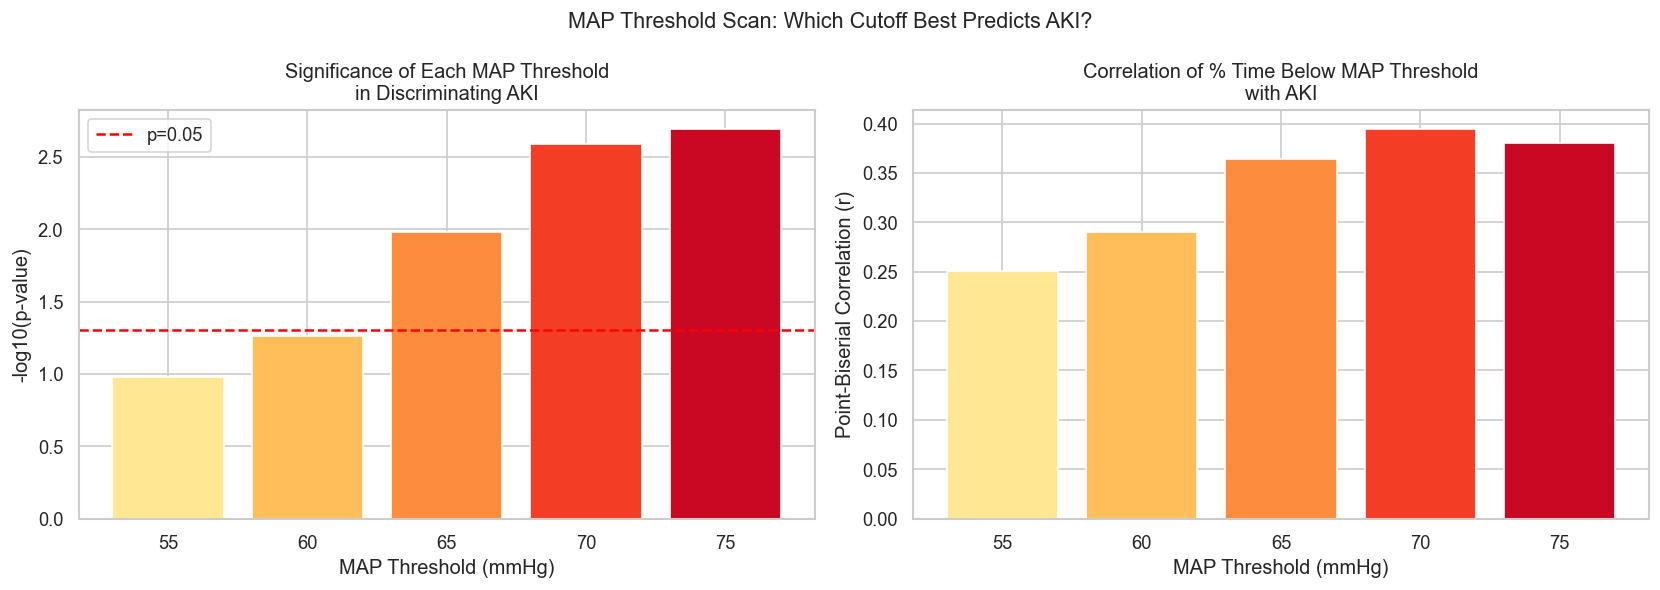

In [7]:
thr_cols = [c for c in hemo.columns if c.startswith('pct_map_lt')]
thresholds = sorted([int(c.replace('pct_map_lt','')) for c in thr_cols])

thr_results = []
for thr in thresholds:
    col = f'pct_map_lt{thr}'
    sub = hemo[[col,'aki_any']].dropna()
    g0, g1 = sub.loc[sub['aki_any']==0,col], sub.loc[sub['aki_any']==1,col]
    _, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    # Point-biserial correlation
    r, _ = stats.pointbiserialr(sub['aki_any'], sub[col])
    thr_results.append({'threshold_mmHg': thr, 'p_value': p, 'r_pb': r,
                         'mean_noaki': g0.mean(), 'mean_aki': g1.mean()})

thr_df = pd.DataFrame(thr_results)
print(thr_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(thr_df['threshold_mmHg'].astype(str), -np.log10(thr_df['p_value'].clip(1e-10)),
            color=sns.color_palette('YlOrRd', len(thr_df)), edgecolor='white')
axes[0].axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1.5, label='p=0.05')
axes[0].set_xlabel('MAP Threshold (mmHg)')
axes[0].set_ylabel('-log10(p-value)')
axes[0].set_title('Significance of Each MAP Threshold\nin Discriminating AKI')
axes[0].legend()

axes[1].bar(thr_df['threshold_mmHg'].astype(str), thr_df['r_pb'],
            color=sns.color_palette('YlOrRd', len(thr_df)), edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('MAP Threshold (mmHg)')
axes[1].set_ylabel('Point-Biserial Correlation (r)')
axes[1].set_title('Correlation of % Time Below MAP Threshold\nwith AKI')

plt.suptitle('MAP Threshold Scan: Which Cutoff Best Predicts AKI?', fontsize=13)
plt.tight_layout()
plt.show()

### What does the threshold scan reveal?

The results are clinically illuminating:

- **MAP 70 mmHg shows the strongest discrimination** — not MAP 65. The bar for MAP < 70 has the highest -log10(p-value) and the strongest point-biserial correlation with AKI. This suggests that the traditional MAP 65 threshold may actually be *too low* as a safety target for the kidneys.
- **MAP 75 also performs well**, reinforcing the idea that keeping MAP above 70–75 mmHg may be more protective for the kidneys than the conventional 65 mmHg floor.
- **MAP 55 shows the weakest signal.** This is not because MAP 55 is "safe" — it is because very few patients spend much time below 55, so there is less statistical power to detect a difference. When MAP does drop to 55, it is often a brief crisis that gets treated quickly.

**Why might a higher threshold matter?** The kidney autoregulates its own blood flow — it can maintain filtration across a range of perfusion pressures by dilating or constricting its afferent arterioles. But this autoregulatory mechanism has limits. In patients with chronic hypertension, diabetes, or pre-existing chronic kidney disease, the lower bound of autoregulation shifts *upward*. For these patients, a MAP of 65 may already be below their autoregulatory threshold, meaning their kidneys are passively losing blood flow even though the textbook says the pressure is "acceptable."

**Practical implication for the anaesthetist:** A one-size-fits-all MAP target of 65 mmHg may not be protective enough, especially in high-risk patients. These data support the growing consensus that individualised blood pressure targets — particularly keeping MAP above 70–75 mmHg in vulnerable populations — may reduce AKI risk.

## 7. Does more hypotension mean more kidney damage? The dose–response question

In pharmacology, one of the most important concepts is the **dose–response relationship**: the more drug you give, the bigger the effect. The same principle can apply to harmful exposures. If intraoperative hypotension truly *causes* kidney injury (rather than merely being associated with it), we would expect a dose–response pattern: patients with more hypotension should have more creatinine rise.

The three scatter plots below test this idea from different angles:

1. **Left panel — % Time MAP < 65 vs Creatinine Ratio:** Does spending a larger fraction of the operation hypotensive lead to a bigger creatinine rise?
2. **Middle panel — MAP Deficit-Minutes vs Creatinine Ratio:** This is the more sophisticated "area under the curve" measure — it accounts for both how *deep* and how *long* each hypotensive episode was. Think of it as the total "dose" of hypotension the kidneys received.
3. **Right panel — Minimum MAP vs Creatinine Ratio:** Does hitting a lower nadir predict a bigger creatinine rise?

In each plot, red dots are AKI patients and blue dots are non-AKI patients. The dashed black line is a linear trend. The orange horizontal line marks the AKI threshold (creatinine ratio of 1.5). The **Pearson correlation coefficient (r)** measures the strength of the linear relationship: r = 0 means no relationship, r = 1 means a perfect positive relationship, and r = -1 means a perfect inverse relationship.

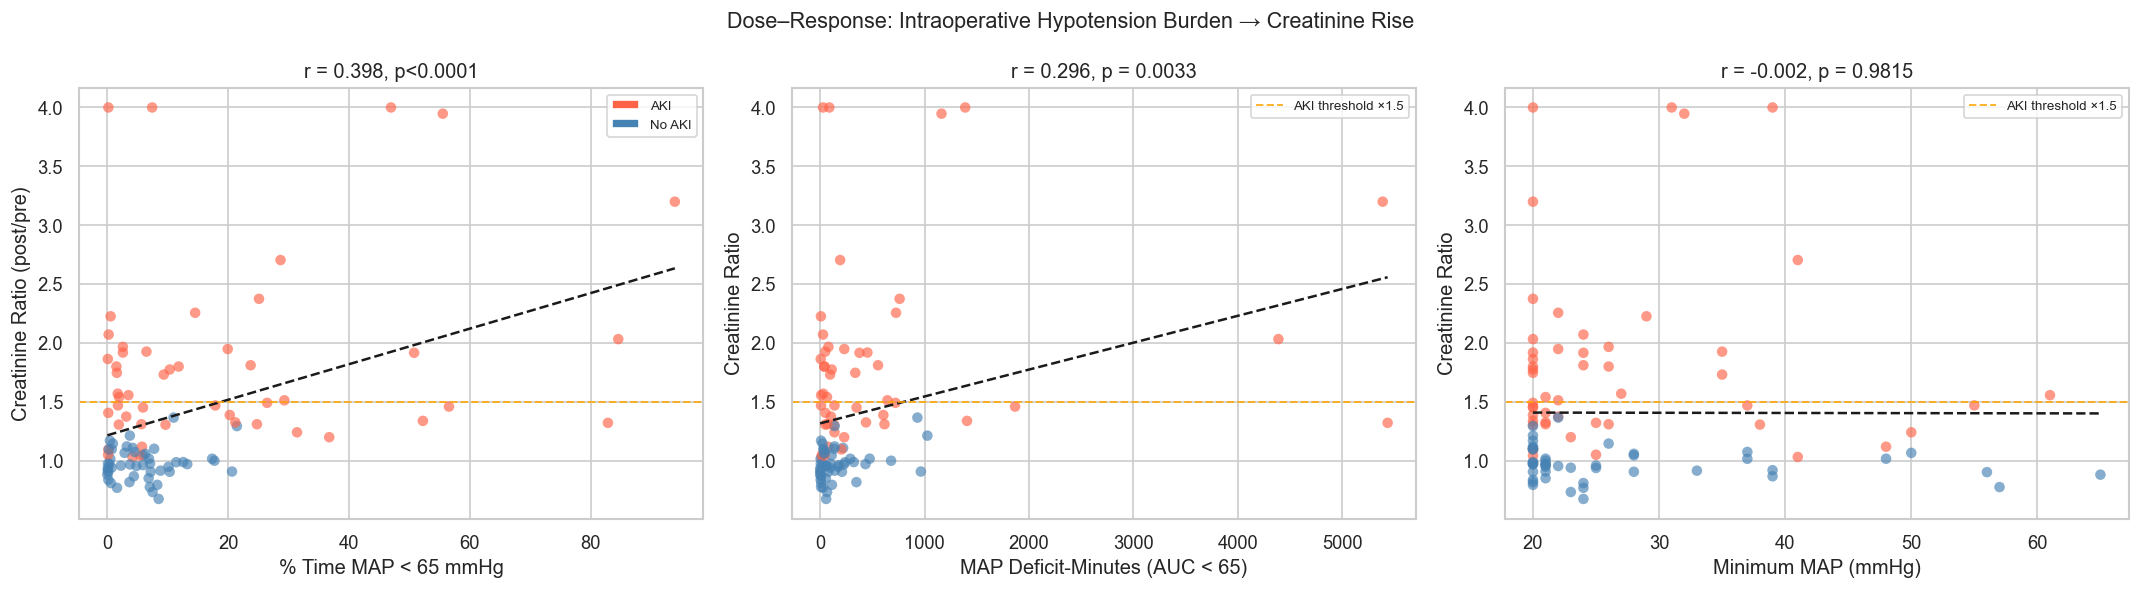

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs_dr = [
    ('pct_map_lt65', 'cr_ratio', '% Time MAP < 65 mmHg', 'Creatinine Ratio (post/pre)'),
    ('auc_lt65',     'cr_ratio', 'MAP Deficit-Minutes (AUC < 65)', 'Creatinine Ratio'),
    ('map_min',      'cr_ratio', 'Minimum MAP (mmHg)', 'Creatinine Ratio'),
]
for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs_dr):
    sub = hemo[[xcol, ycol, 'aki_any']].dropna()
    colors_pt = sub['aki_any'].map({0:'steelblue', 1:'tomato'})
    ax.scatter(sub[xcol], sub[ycol].clip(0,4), c=colors_pt, alpha=0.65, s=40, edgecolors='none')
    # Trend line
    z = np.polyfit(sub[xcol], sub[ycol].clip(0,4), 1)
    xr = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
    ax.plot(xr, np.polyval(z, xr), 'k--', linewidth=1.5)
    # AKI threshold
    ax.axhline(1.5, color='orange', linestyle='--', linewidth=1.2, alpha=0.8, label='AKI threshold ×1.5')
    r, p = stats.pearsonr(sub[xcol], sub[ycol].clip(0,4))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'r = {r:.3f}, p = {p:.4f}' if p >= 0.0001 else f'r = {r:.3f}, p<0.0001')
    ax.legend(fontsize=8)

# Legend for colour
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='tomato', label='AKI'), Patch(facecolor='steelblue', label='No AKI')]
axes[0].legend(handles=legend_elems + axes[0].get_legend_handles_labels()[0][1:], fontsize=8)

plt.suptitle('Dose–Response: Intraoperative Hypotension Burden → Creatinine Rise', fontsize=13)
plt.tight_layout()
plt.show()

### The physiological story behind these scatter plots

Let's walk through each panel:

**Left panel (% Time MAP < 65):** There is a positive correlation — the more time a patient spends hypotensive, the higher their creatinine ratio tends to be. Notice, however, that the relationship is modest and there is a lot of scatter. Many patients who spent significant time below MAP 65 did *not* develop AKI (blue dots above 5–10% on the x-axis). This reminds us that the kidney has compensatory mechanisms — autoregulation, tubuloglomerular feedback, and neurohormonal responses — that can protect against moderate insults. But these defences have limits.

**Middle panel (MAP Deficit-Minutes):** This panel shows a similar but often slightly stronger trend. Deficit-minutes capture the *total dose* of hypotension: a MAP of 55 for 10 minutes (10 mmHg deficit x 10 minutes = 100 deficit-minutes) is treated as equivalent to a MAP of 60 for 20 minutes (5 x 20 = 100 deficit-minutes). The concentration of red dots (AKI) toward the right side of the plot — high deficit-minutes — supports the idea that cumulative hypotensive burden, not just a single threshold crossing, drives kidney injury.

**Right panel (Minimum MAP):** Interestingly, the minimum MAP shows a weaker or absent correlation with creatinine ratio. This is consistent with what we saw in the box plots: a single brief nadir does not predict AKI very well. The kidneys can tolerate a brief low point if perfusion is quickly restored. What they cannot tolerate is *sustained* or *repeated* low pressure.

**The clinical "so what?":** These plots support a dose–response relationship between intraoperative hypotension and kidney injury. This is one of the Bradford Hill criteria for inferring causality from observational data — if the association shows a dose–response gradient, it is more likely to be causal rather than confounded. For the anaesthetist, this means that *every minute* of hypotension counts. There is no single "safe" dip; rather, the goal should be to minimise the cumulative burden of time spent below the patient's autoregulatory threshold.

## 8. Does blood pressure *instability* matter, beyond the average?

So far we have focused on how low the blood pressure goes. But what about how much it *fluctuates*? Two patients might have the same mean MAP, but one has a steady trace while the other oscillates wildly between hypertension and hypotension. Are these equivalent for the kidneys?

We look at four measures of variability:

- **SBP standard deviation (SD):** How spread out the systolic readings are around their mean. Higher SD = more variation.
- **SBP beat-to-beat lability (successive squared differences):** Instead of looking at overall spread, this measures how much the blood pressure changes from *one heartbeat to the next*. A patient with gradual drifts has low lability; a patient whose pressure jumps 20 mmHg between beats has high lability.
- **Mean pulse pressure:** The average difference between systolic and diastolic. Narrow pulse pressure (< 20 mmHg) can indicate low cardiac output or cardiac tamponade. Very wide pulse pressure (> 60 mmHg) may indicate aortic regurgitation or stiff, atherosclerotic arteries.
- **% Time with narrow pulse pressure (< 20 mmHg):** Time spent with a dangerously narrow pulse pressure — a potential marker of low cardiac output states.

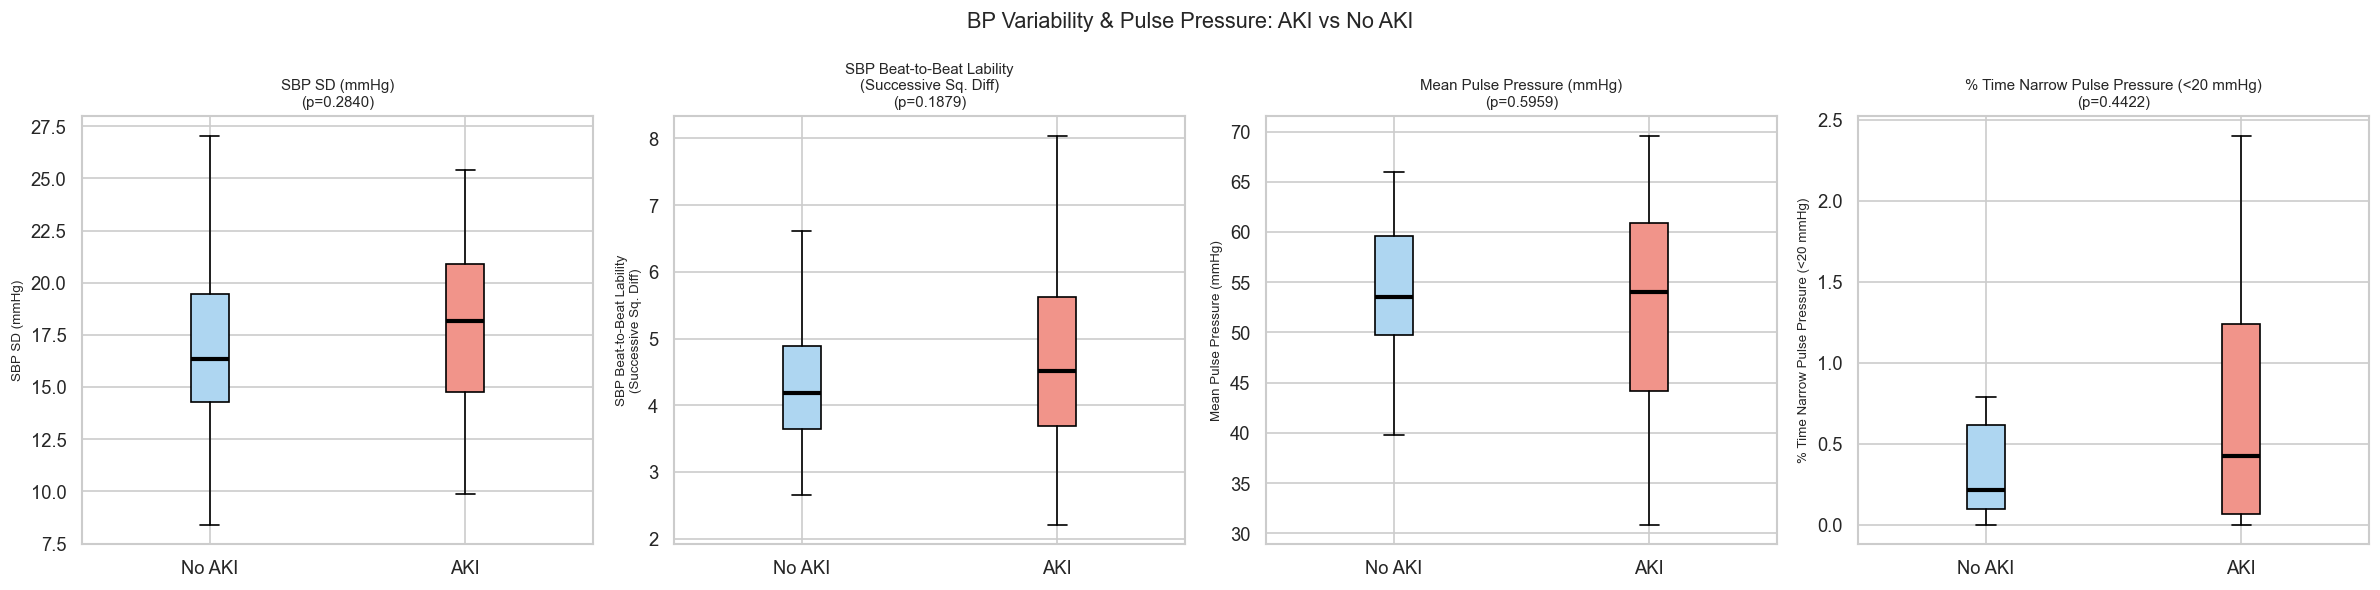

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
variability_pairs = [
    ('sbp_sd',        'SBP SD (mmHg)'),
    ('sbp_ssd',       'SBP Beat-to-Beat Lability\n(Successive Sq. Diff)'),
    ('pp_mean',       'Mean Pulse Pressure (mmHg)'),
    ('pct_pp_narrow', '% Time Narrow Pulse Pressure (<20 mmHg)'),
]
for ax, (col, title) in zip(axes, variability_pairs):
    if col not in hemo.columns: ax.set_visible(False); continue
    g0 = hemo.loc[hemo['aki_any']==0, col].dropna()
    g1 = hemo.loc[hemo['aki_any']==1, col].dropna()
    if len(g0)==0 or len(g1)==0: ax.set_visible(False); continue
    _, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    pstr = f'p={p:.4f}' if p>=0.0001 else 'p<0.0001'
    bp = ax.boxplot([g0, g1], labels=['No AKI', 'AKI'],
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#F1948A')
    ax.set_title(f'{title}\n({pstr})', fontsize=9)
    ax.set_ylabel(title, fontsize=8)

plt.suptitle('BP Variability & Pulse Pressure: AKI vs No AKI', fontsize=13)
plt.tight_layout()
plt.show()

### Interpreting the variability findings

The variability metrics tell a more nuanced story than the threshold-based measures:

- **SBP variability** (SD and beat-to-beat lability) may show modest differences between groups, but they are generally less discriminating than the hypotension-burden metrics. This does not mean variability is unimportant — it may interact with hypotension in complex ways — but on its own, it is a weaker predictor.
- **Pulse pressure** findings are clinically interesting. If AKI patients show a narrower mean pulse pressure, this could reflect lower cardiac output — fewer millilitres of blood ejected per heartbeat. Remember, the kidney cares about *flow*, not just pressure. A patient with a MAP of 70 but very low cardiac output may have worse renal perfusion than a patient with a MAP of 65 but a vigorous cardiac output.
- **Narrow pulse pressure episodes** (< 20 mmHg) may identify periods when the heart is struggling — whether from hypovolaemia, myocardial depression from anaesthetic agents, or an acute cardiac event.

**Clinical take-away:** Blood pressure variability and pulse pressure add complementary information beyond mean MAP and hypotension duration. They hint at the *haemodynamic mechanism* — whether the problem is primarily vascular (vasodilation from anaesthesia) or cardiac (low output).

## 9. What does the overall MAP distribution look like in each group?

Another way to compare the groups is to pool *all* the MAP readings from all patients in each group and plot a single histogram — a frequency distribution. This shows us the "shape" of MAP values: where the bulk of readings fall, how much of the distribution sits below critical thresholds, and whether the distributions are symmetrical or skewed.

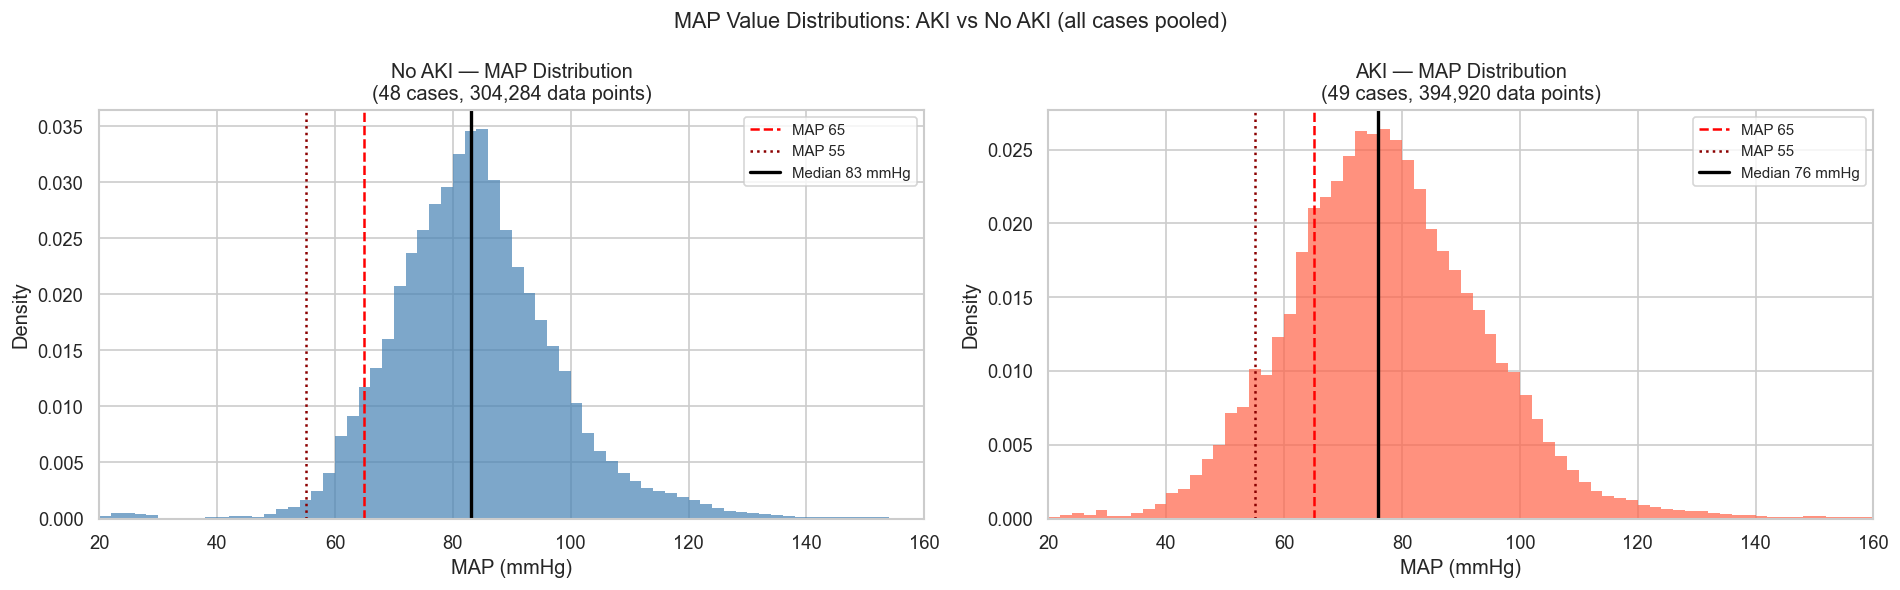

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (aki_val, color, label) in zip([axes[0], axes[1]],
    [(0, 'steelblue', 'No AKI'), (1, 'tomato', 'AKI')]):
    case_ids = hemo[hemo['aki_any']==aki_val]['caseid'].tolist()
    all_vals = art[(art['signal']=='ART_MBP') & art['caseid'].isin(case_ids)]['value']
    ax.hist(all_vals, bins=80, color=color, edgecolor='none', alpha=0.7, density=True)
    ax.axvline(65,  color='red',    linestyle='--', linewidth=1.5, label='MAP 65')
    ax.axvline(55,  color='darkred',linestyle=':',  linewidth=1.5, label='MAP 55')
    ax.axvline(all_vals.median(), color='black', linestyle='-', linewidth=2,
               label=f'Median {all_vals.median():.0f} mmHg')
    ax.set_xlabel('MAP (mmHg)')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} — MAP Distribution\n'
                 f'({len(case_ids)} cases, {len(all_vals):,} data points)')
    ax.legend(fontsize=9)
    ax.set_xlim(20, 160)

plt.suptitle('MAP Value Distributions: AKI vs No AKI (all cases pooled)', fontsize=13)
plt.tight_layout()
plt.show()

### Reading the MAP distributions

Compare the two histograms side by side:

- **The AKI distribution is shifted slightly to the left**, confirming that AKI patients, on the whole, spent more of their intraoperative time at lower MAP values. The median (black vertical line) sits a few mmHg lower in the AKI group.
- **The left tail (below MAP 65) is fatter in the AKI group.** More of the distribution's area falls below the red dashed threshold line. This is the graphical equivalent of "higher % time MAP < 65."
- **Both distributions are roughly bell-shaped** but with slight right skew — there are occasional hypertensive spikes (MAP > 120) in both groups, likely reflecting responses to surgical stimulation or emergence from anaesthesia.

This view complements the per-case feature analysis: it shows that the group-level signal (AKI patients have lower MAPs) is not driven by a handful of extreme outliers but is a consistent shift across many patients.

## 10. Can we see all patients at once? The MAP heatmap

Heatmaps let us visualise the entire cohort simultaneously. Each row is one patient, each column is a time point (normalised from 0% to 100% of case duration), and the colour represents the MAP at that moment: green for high MAP (well-perfused) and red for low MAP (potentially under-perfused).

Patients are sorted from bottom to top by their mean MAP, so the sickest patients (lowest average MAP) appear at the top. This layout lets you instantly see whether the AKI group has more "red" (low MAP) overall, and whether the patterns of hypotension differ — is it concentrated at certain phases of surgery, or spread throughout?

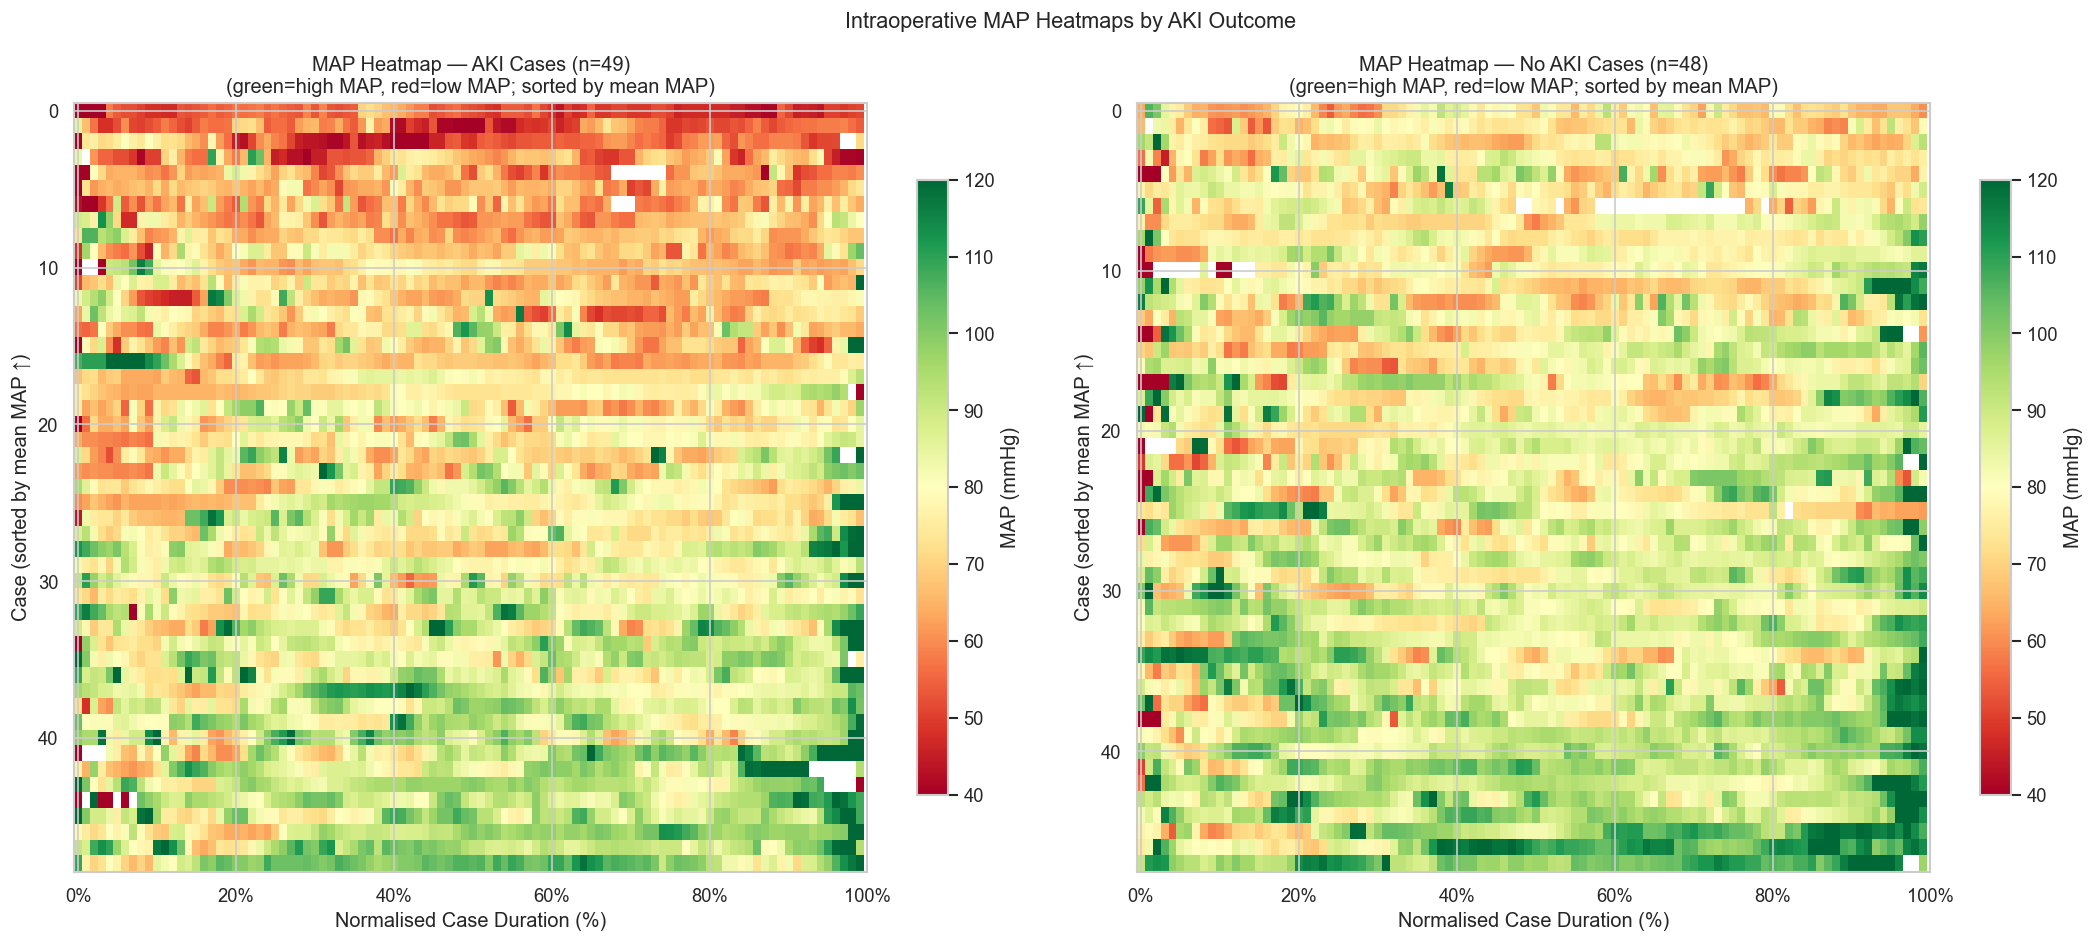

In [11]:
N_BINS = 100

def build_matrix(caseid_list, signal='ART_MBP', n_bins=N_BINS):
    rows = []
    cids_out = []
    for cid in caseid_list:
        s = art[(art['caseid']==cid) & (art['signal']==signal)].sort_values('time_s')
        if len(s) < 20: continue
        t = s['time_s'].values
        v = s['value'].values
        t_norm = (t - t.min()) / (t.max() - t.min()) * 100
        bins = np.floor(t_norm / (100/n_bins)).astype(int).clip(0, n_bins-1)
        trace = pd.Series(v).groupby(bins).median().reindex(range(n_bins))
        rows.append(trace.values)
        cids_out.append(cid)
    return np.array(rows), cids_out

aki_ids_list   = hemo[hemo['aki_any']==1]['caseid'].tolist()
noaki_ids_list = hemo[hemo['aki_any']==0]['caseid'].tolist()

mat_aki,   cids_aki   = build_matrix(aki_ids_list)
mat_noaki, cids_noaki = build_matrix(noaki_ids_list)

# Sort by mean MAP (ascending — sickest at top)
sort_aki   = np.argsort(np.nanmean(mat_aki,   axis=1))
sort_noaki = np.argsort(np.nanmean(mat_noaki, axis=1))
mat_aki   = mat_aki[sort_aki]
mat_noaki = mat_noaki[sort_noaki]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, mat, title in [
    (axes[0], mat_aki,   f'AKI Cases (n={len(mat_aki)})'),
    (axes[1], mat_noaki, f'No AKI Cases (n={len(mat_noaki)})'),
]:
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=40, vmax=120,
                   interpolation='nearest')
    ax.set_xlabel('Normalised Case Duration (%)')
    ax.set_ylabel('Case (sorted by mean MAP ↑)')
    ax.set_title(f'MAP Heatmap — {title}\n(green=high MAP, red=low MAP; sorted by mean MAP)')
    ax.set_xticks(np.arange(0, N_BINS+1, 20))
    ax.set_xticklabels([f'{v}%' for v in range(0, 101, 20)])
    plt.colorbar(im, ax=ax, label='MAP (mmHg)', shrink=0.8)

plt.suptitle('Intraoperative MAP Heatmaps by AKI Outcome', fontsize=13)
plt.tight_layout()
plt.show()

### Reading the heatmaps

Compare the two panels:

- **The AKI heatmap typically shows more red and yellow** (lower MAP values), particularly among the top rows (the sickest patients). Some of these patients have entire operations painted in warm colours — sustained, whole-case hypotension.
- **The non-AKI heatmap tends to be greener**, meaning these patients maintained higher MAPs throughout their operations. Even the lower-MAP patients in this group often have only brief orange bands.
- **Look for horizontal red streaks** in the AKI panel — these represent patients who were hypotensive for extended, uninterrupted periods. These are the high-risk patients that the "longest hypotension run" feature was designed to capture.
- **Early-case dips** (around the 5–10% mark) are visible in both groups, corresponding to induction hypotension. The difference is in recovery: non-AKI patients tend to restore their MAP more quickly and maintain it.

**Why this visualisation matters:** Heatmaps give the clinician a gestalt that no single number can. They show that AKI is not typically caused by a single dramatic crash, but by a pattern of sustained or recurrent hypotension — the blood pressure equivalent of "death by a thousand cuts."

## 11. Can we build a predictive model? ROC analysis

Now we bring everything together. We feed all our arterial line features — MAP statistics, hypotension burden, variability measures, pulse pressure, plus patient age and ASA status — into a **logistic regression** model that tries to predict which patients will develop AKI.

### A brief primer on key concepts

- **Logistic regression** is a statistical model that predicts the probability of a binary outcome (AKI vs no AKI) based on one or more input variables. It is the workhorse of clinical prediction modelling — simple enough to interpret, powerful enough to be useful.
- **Cross-validation (CV):** Instead of training and testing the model on the same data (which would be overly optimistic), we use **5-fold cross-validation**. We split the data into 5 equal parts, train on 4 parts, test on the 1 held-out part, and repeat 5 times. The reported AUC is the average across all 5 folds — a more honest estimate of how the model would perform on new, unseen patients.
- **AUC (Area Under the ROC Curve):** The ROC curve plots the true positive rate (sensitivity — how many AKI patients did we correctly identify?) against the false positive rate (1 - specificity — how many non-AKI patients did we incorrectly flag?) at every possible probability threshold. The AUC summarises this trade-off in a single number: 0.5 = no better than a coin flip, 0.7–0.8 = acceptable discrimination, 0.8–0.9 = good, > 0.9 = excellent.
- **Standardised coefficients:** After fitting the model, we can look at the coefficient for each feature. A positive coefficient means that feature *increases* the predicted risk of AKI; a negative coefficient means it is *protective*. Because the features are on different scales (some in mmHg, some in percentages, some in minutes), we standardise them first so the coefficients are directly comparable in magnitude.

In [12]:
predictor_cols = [
    'map_mean', 'map_min', 'map_sd', 'map_cv',
    'pct_map_lt55', 'pct_map_lt60', 'pct_map_lt65', 'pct_map_lt70',
    'auc_lt65', 'auc_lt75', 'max_hypo_run', 'n_hypo_episodes',
    'sbp_sd', 'sbp_ssd', 'pp_mean', 'pct_pp_narrow',
    'duration_min', 'age', 'asa',
]
predictors = [p for p in predictor_cols if p in hemo.columns]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sub = hemo[predictors + ['aki_any']].dropna()
X = sub[predictors].values
y = sub['aki_any'].values.astype(int)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42))
])
cv_aucs = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
pipe.fit(X, y)
y_prob = pipe.predict_proba(X)[:,1]
fpr, tpr, thrs = roc_curve(y, y_prob)
full_auc = roc_auc_score(y, y_prob)
coefs = pd.Series(pipe.named_steps['lr'].coef_[0], index=predictors).sort_values(key=abs, ascending=False)

print(f'Cross-validated AUC : {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}')
print(f'Full-data AUC        : {full_auc:.3f}')
print(f'n={len(y)}, positives={int(y.sum())}')

# Individual ROC curves for single best features
single_aucs = {}
for col in ['pct_map_lt65','auc_lt65','map_min','map_sd','sbp_ssd','max_hypo_run']:
    if col not in hemo.columns: continue
    s = hemo[[col,'aki_any']].dropna()
    if s['aki_any'].sum() < 2: continue
    fpr_s, tpr_s, _ = roc_curve(s['aki_any'], s[col])
    single_aucs[col] = (roc_auc_score(s['aki_any'], s[col]), fpr_s, tpr_s)

Cross-validated AUC : 0.736 ± 0.125
Full-data AUC        : 0.844
n=95, positives=47


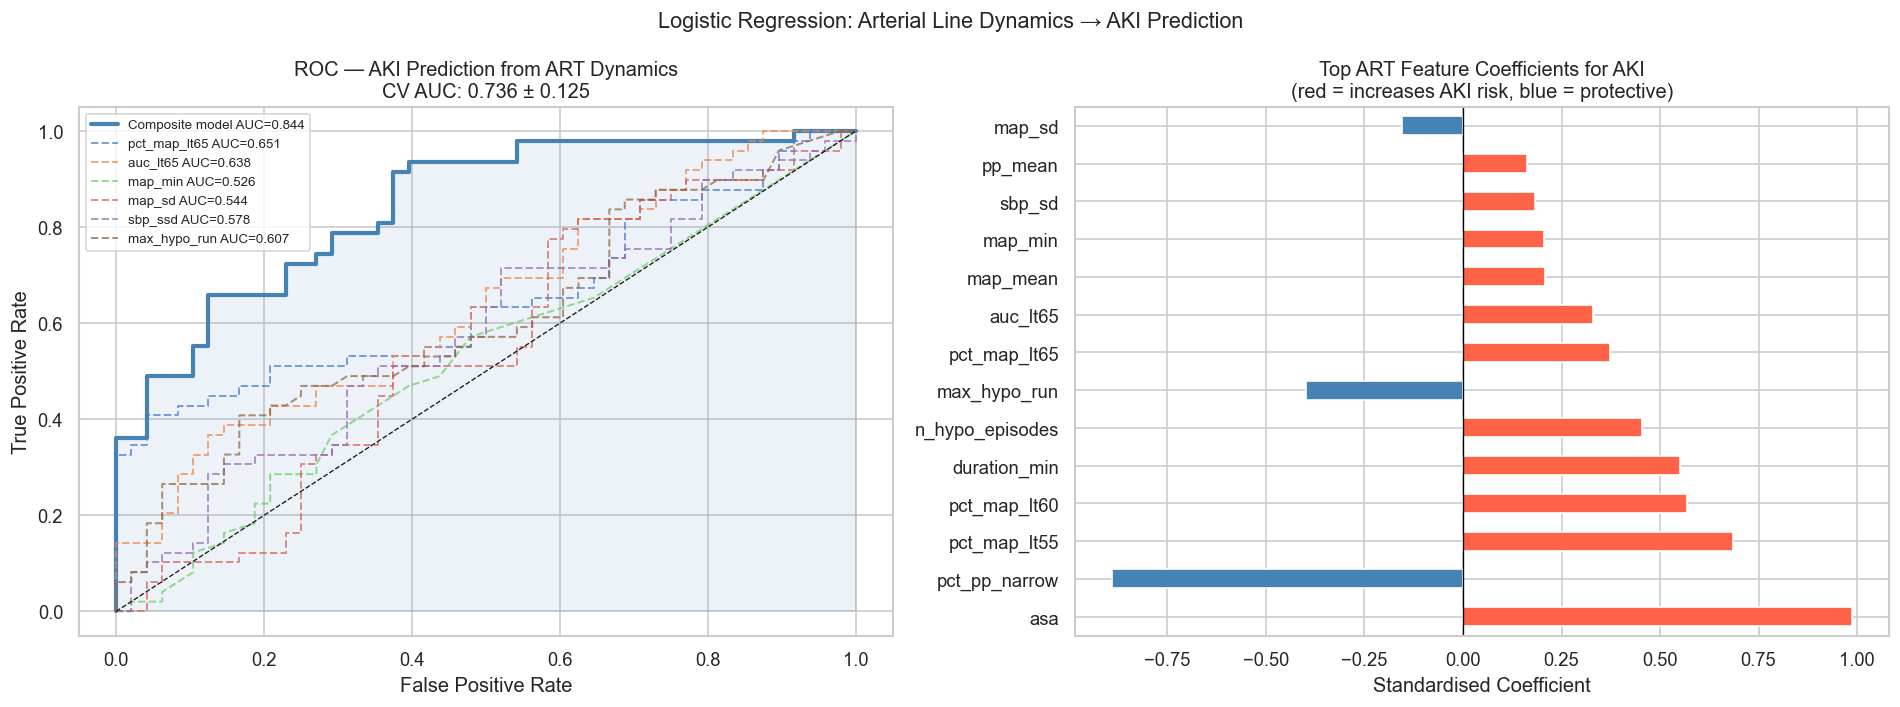

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Composite model ROC
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'Composite model AUC={full_auc:.3f}')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
for col, (auc_s, fpr_s, tpr_s) in single_aucs.items():
    axes[0].plot(fpr_s, tpr_s, linewidth=1.2, linestyle='--', alpha=0.7,
                 label=f'{col} AUC={max(auc_s, 1-auc_s):.3f}')
axes[0].plot([0,1],[0,1],'k--',linewidth=0.8)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC — AKI Prediction from ART Dynamics\nCV AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}')
axes[0].legend(fontsize=8)

# Feature coefficients
top_coefs = coefs.head(14)
colors_c = ['tomato' if c > 0 else 'steelblue' for c in top_coefs.values]
top_coefs.plot(kind='barh', ax=axes[1], color=colors_c, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top ART Feature Coefficients for AKI\n(red = increases AKI risk, blue = protective)')
axes[1].set_xlabel('Standardised Coefficient')

plt.suptitle('Logistic Regression: Arterial Line Dynamics → AKI Prediction', fontsize=13)
plt.tight_layout()
plt.show()

### Interpreting the ROC results

**Left panel — ROC curves:**
- The **composite model** (solid blue line) achieves a cross-validated AUC of about 0.74. This means that if you picked a random AKI patient and a random non-AKI patient, the model would correctly rank the AKI patient as higher risk about 74% of the time. This is a moderate but clinically meaningful level of discrimination — especially considering we are using *only* arterial line features, without any laboratory values, surgical complexity data, or pre-existing comorbidities.
- The individual features (dashed lines) generally perform worse than the composite, as expected — combining multiple pieces of information outperforms any single metric. However, some individual features like % time MAP < 65 and MAP deficit-minutes show respectable discrimination on their own.
- The gap between the full-data AUC (~0.84) and the CV AUC (~0.74) suggests some overfitting — the model memorises some noise in the training data. The CV AUC is the more trustworthy estimate of real-world performance.

**Right panel — Feature coefficients:**
- **ASA physical status** emerges as the strongest predictor (largest coefficient). This makes physiological sense: ASA class captures the patient's overall fitness and comorbidity burden, which influences both the likelihood of intraoperative haemodynamic instability and the kidney's resilience to hypotensive insults.
- **Hypotension-burden features** (% time below thresholds, AUC measures) appear with positive coefficients — more hypotension predicts more AKI risk.
- **Higher mean MAP** has a protective (negative) coefficient — as expected, patients who maintained higher average pressures were less likely to develop AKI.

**Honest limitations:** With only ~97 cases and 19 features, this model is exploratory. The wide confidence interval on the CV AUC (plus or minus 0.125) reflects the small sample size. A larger cohort and external validation would be needed before using such a model clinically.

## 12. Is there a "safe amount" of hypotension? Binned dose–response

To make the dose–response relationship even more concrete, we divide patients into groups based on how much time they spent below MAP 65: none at all (0%), a little (0–2%), moderate (2–5%), and so on up to more than 20%. For each bin, we calculate the AKI rate and the average creatinine ratio.

If hypotension drives AKI in a dose-dependent manner, we expect a staircase pattern: each step up in hypotension burden should correspond to a step up in AKI rate and creatinine rise.

           n  aki_rate  mean_cr_ratio  mean_map
hypo_bin                                       
0%         1      0.00           0.88     91.44
0–2%      27     48.15           1.43     89.08
2–5%      15     33.33           1.20     86.73
5–10%     21     38.10           2.52     82.08
10–20%    13     38.46           1.34     78.27
>20%      20     90.00           2.00     67.96


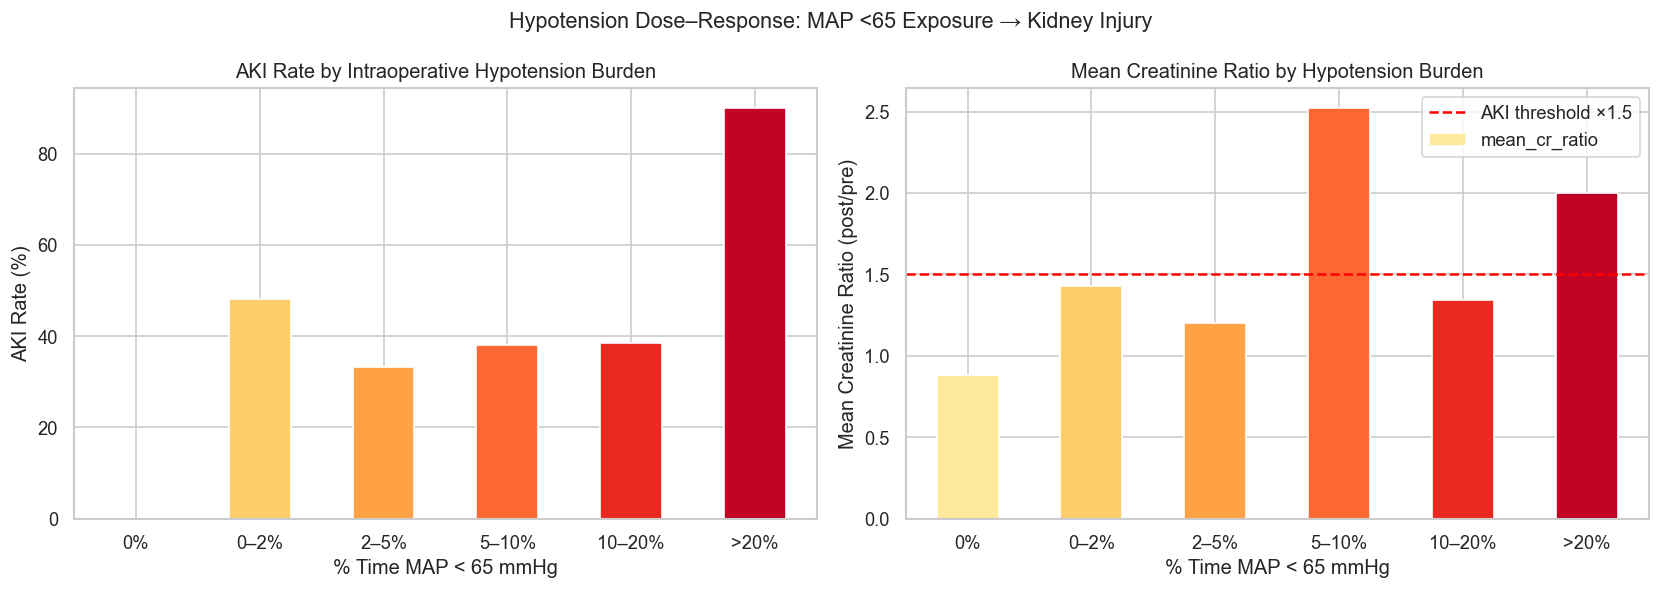

In [14]:
hemo['hypo_bin'] = pd.cut(
    hemo['pct_map_lt65'],
    bins=[-0.01, 0, 2, 5, 10, 20, 100],
    labels=['0%', '0–2%', '2–5%', '5–10%', '10–20%', '>20%']
)
hypo_summary = (
    hemo.groupby('hypo_bin', observed=True)
    .agg(
        n           = ('caseid','count'),
        aki_rate    = ('aki_any', lambda x: x.mean()*100),
        mean_cr_ratio = ('cr_ratio','mean'),
        mean_map    = ('map_mean','mean'),
    ).round(2)
)
print(hypo_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = sns.color_palette('YlOrRd', len(hypo_summary))

hypo_summary['aki_rate'].plot(kind='bar', ax=axes[0], color=pal, edgecolor='white', rot=0)
axes[0].set_title('AKI Rate by Intraoperative Hypotension Burden')
axes[0].set_xlabel('% Time MAP < 65 mmHg')
axes[0].set_ylabel('AKI Rate (%)')

hypo_summary['mean_cr_ratio'].plot(kind='bar', ax=axes[1], color=pal, edgecolor='white', rot=0)
axes[1].axhline(1.5, color='red', linestyle='--', linewidth=1.5, label='AKI threshold ×1.5')
axes[1].set_title('Mean Creatinine Ratio by Hypotension Burden')
axes[1].set_xlabel('% Time MAP < 65 mmHg')
axes[1].set_ylabel('Mean Creatinine Ratio (post/pre)')
axes[1].legend()

plt.suptitle('Hypotension Dose–Response: MAP <65 Exposure → Kidney Injury', fontsize=13)
plt.tight_layout()
plt.show()

### The staircase pattern

The bar charts above show the dose–response relationship in its most intuitive form:

- **Left panel (AKI rate):** As the hypotension burden increases (moving from left to right along the x-axis), the AKI rate generally climbs. Patients who spent no time below MAP 65 have the lowest AKI rate, while those who spent more than 20% of their operation hypotensive have the highest. This staircase pattern is exactly what we would expect if the relationship were causal.
- **Right panel (mean creatinine ratio):** Similarly, the average creatinine ratio rises with increasing hypotension burden. The red dashed line at 1.5 marks the KDIGO AKI threshold — note how the higher-burden bins approach or exceed this line.

**A word of caution:** These bins have small numbers of patients each, so the pattern may not be perfectly monotonic (you may see a bin that bucks the trend). Small-sample fluctuations are normal. The overall upward trend is what matters.

**Clinical implication:** There does not appear to be a clear "safe" duration of hypotension. Even modest amounts of time below MAP 65 (2–5%) are associated with a higher AKI rate than zero hypotension. This supports the principle that anaesthetists should aim to minimise *any* time below the target MAP, not just avoid catastrophic drops.

## 13. What have we learned? Bringing it all together

Let's step back and summarise the key findings from this analysis. The code below prints the headline numbers, followed by our narrative interpretation.

In [15]:
best_feat = thr_df.loc[thr_df['r_pb'].abs().idxmax(), 'threshold_mmHg']
print('=' * 62)
print('ARTERIAL LINE DYNAMICS → AKI  —  KEY FINDINGS')
print('=' * 62)
print(f'Fetched cases (AKI={hemo["aki_any"].sum()}, No AKI={(hemo["aki_any"]==0).sum()})')
print()
for col, lbl in [('map_mean','Mean MAP'), ('map_min','Min MAP'),
                  ('pct_map_lt65','% Time MAP<65'), ('auc_lt65','MAP Deficit-Min')]:
    if col not in hemo.columns: continue
    g0 = hemo.loc[hemo['aki_any']==0, col].dropna()
    g1 = hemo.loc[hemo['aki_any']==1, col].dropna()
    _, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    print(f'{lbl:28s}: No AKI={g0.median():.1f}  AKI={g1.median():.1f}  p={p:.4f}')
print()
print(f'Best discriminating threshold : MAP < {best_feat} mmHg')
print(f'Composite ART model CV AUC    : {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}')
print(f'Top AKI predictor             : {coefs.index[0]} (coef={coefs.iloc[0]:.3f})')
print('=' * 62)

ARTERIAL LINE DYNAMICS → AKI  —  KEY FINDINGS
Fetched cases (AKI=49, No AKI=48)

Mean MAP                    : No AKI=84.1  AKI=79.6  p=0.0087
Min MAP                     : No AKI=21.0  AKI=22.0  p=0.6523
% Time MAP<65               : No AKI=4.7  AKI=9.3  p=0.0105
MAP Deficit-Min             : No AKI=72.0  AKI=137.0  p=0.0196

Best discriminating threshold : MAP < 70 mmHg
Composite ART model CV AUC    : 0.736 ± 0.125
Top AKI predictor             : asa (coef=0.987)


### The big picture

This notebook demonstrates that the arterial line — a monitor already present in every high-risk surgical case — contains information that is predictive of postoperative kidney injury. Here are the key lessons:

**1. Cumulative burden matters more than a single nadir.**
The minimum MAP during surgery did not significantly differ between AKI and non-AKI patients. But the *percentage of time* spent below MAP 65, the *total deficit-minutes*, and the *longest unbroken hypotensive episode* all showed significant differences. The kidney injury appears to be a cumulative insult, not a single event.

**2. MAP 65 may not be protective enough.**
Our threshold scan found that MAP 70 — not the traditional 65 — was the most discriminating cutoff. This aligns with recent literature suggesting that individualised, higher MAP targets may be needed, particularly for patients with chronic hypertension, diabetes, or pre-existing renal disease, whose autoregulatory curves are shifted rightward.

**3. There is a dose–response relationship.**
More hypotension leads to more creatinine rise, both in continuous scatter plots and in binned analyses. This dose–response gradient strengthens the case for a causal link (though observational data alone cannot prove causation).

**4. A simple model using only arterial line features achieves moderate predictive performance.**
A logistic regression model using haemodynamic features plus ASA class achieved a cross-validated AUC of approximately 0.74. While not sufficient for clinical deployment, this demonstrates that the arterial trace contains meaningful prognostic information that could be incorporated into real-time decision support systems.

**5. ASA class is a powerful confounder — and a reminder of patient complexity.**
The strongest predictor in our model was ASA physical status, not any single haemodynamic metric. Sicker patients (higher ASA) are more likely to become hypotensive *and* more likely to develop AKI, regardless of their blood pressure management. This is a classic example of confounding: the same underlying disease burden drives both the exposure (hypotension) and the outcome (AKI). Disentangling causation from association requires more sophisticated methods (propensity scoring, instrumental variables, or randomised trials).

### Limitations

- **Small sample size** (n = 97 with full features): our findings are exploratory and should be validated in a larger cohort.
- **Observational design:** we cannot distinguish whether hypotension *caused* AKI or was merely a marker of overall illness severity.
- **No information on interventions:** we do not know what vasopressors, fluids, or other treatments were given — the hypotension we observe may have been treated aggressively in some cases and not in others.
- **AKI is multifactorial:** nephrotoxic drugs, sepsis, contrast agents, and surgical factors all contribute to kidney injury. Blood pressure is only one piece of the puzzle.

### What would a thoughtful anaesthetist do with this information?

1. **Monitor cumulative hypotension burden, not just isolated readings.** Modern monitors and electronic health records can track time below threshold in real time.
2. **Consider higher MAP targets** (70–75 mmHg) in patients with risk factors for AKI — older age, diabetes, chronic hypertension, chronic kidney disease, or high ASA class.
3. **Treat hypotension promptly.** Every additional minute below the patient's autoregulatory threshold contributes to the cumulative dose of ischaemia the kidneys receive.
4. **Think about mechanism, not just numbers.** Is the hypotension from vasodilation (treat with vasopressors) or from low cardiac output (treat with fluids or inotropes)? Pulse pressure may help differentiate.